In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import json

In [2]:
import decision_infovalue

# MIMIC-CXR

In [3]:
method_list = ["grpo_cxr_base", "grpo_cxr_0"]

In [4]:
all_concept_data = pd.read_csv(f"data_compl_signal/cxr_foundation_dataset.csv")

for concept in method_list:
    concept_data = pd.read_csv(f"data_compl_signal/infer_{concept}.csv")
    # if concept == "dspy_0":
    concept_data.loc[:, f"{concept}_concepts"] = concept_data["concepts"]
    # else:
    #     concept_data.loc[:, f"{concept}_concepts"] = concept_data["original_concepts"]
    all_concept_data = pd.concat([all_concept_data, concept_data[[f"{concept}_concepts"]]], axis=1)
all_concept_data

,study_id,Unnamed: 0,abnormal_stratified,diagnosis,densenet121_pred,inception_v3_pred,swin_b_pred,resnet50_pred,vit_b_16_pred,path,cxr_foundation_pred_proba,grpo_cxr_base_concepts,grpo_cxr_0_concepts
0,50001372,7042,False,0.0,0.1,0.1,0.1,0.2,0.0,files/p14/p14740030/s50001372.txt,0.035477,[],"[{'name': 'cardiac_dimensions_normal', 'descri..."
1,50001867,7938,True,0.0,0.1,0.2,0.1,0.2,0.1,files/p15/p15649581/s50001867.txt,0.035176,[],"[{'name': 'cardiac_size_normal', 'description'..."
2,50001886,3554,False,1.0,0.3,0.4,0.2,0.1,0.5,files/p11/p11327070/s50001886.txt,0.611171,"[{'name': 'bilateral_pleural_effusions', 'desc...","[{'name': 'pleural_effusions_bilateral', 'desc..."
3,50005580,4709,False,1.0,0.9,0.6,0.7,0.8,0.8,files/p12/p12456080/s50005580.txt,0.790521,"[{'name': 'pleural_effusion', 'description': '...","[{'name': 'heart_enlargement_signal', 'descrip..."
4,50005852,3601,False,0.0,0.4,0.4,0.6,0.5,0.4,files/p11/p11380379/s50005852.txt,0.335822,"[{'name': 'mild_cardiomegaly', 'description': ...","[{'name': 'heart_size_enlargement_signal', 'de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12141,59996255,6416,False,0.0,0.1,0.2,0.1,0.1,0.1,files/p14/p14153350/s59996255.txt,0.035147,[],"[{'name': 'cardiac_size_normal', 'description'..."
12142,59996457,11337,False,0.0,0.1,0.1,0.1,0.1,0.1,files/p19/p19131119/s59996457.txt,0.101974,[],"[{'name': 'cardiac_size_normal', 'description'..."
12143,59996905,4571,False,0.0,0.1,0.1,0.0,0.0,0.0,files/p12/p12309846/s59996905.txt,0.014788,[],"[{'name': 'cardiac_size_normal', 'description'..."
12144,59998636,7806,True,0.0,0.8,0.5,0.7,0.5,0.7,files/p15/p15526064/s59998636.txt,0.883064,"[{'name': 'cardiac_silhouette_enlarged', 'desc...","[{'name': 'cardiac_enlargement_signal', 'descr..."


In [92]:
reports_df = pd.read_csv("data_compl_signal/cxr_foundations_train_dataset_GRPO_0.csv")
reports_df.loc[11366, "report"]

'                                 FINAL REPORT\n INDICATION:  ___M with SOB  // SOB/DOE\n \n TECHNIQUE:  Frontal and lateral chest radiographs were obtained with the\n patient in the upright position.\n \n COMPARISON:  Chest radiographs dating back to ___.\n \n FINDINGS: \n \n Continued opacity obscuring the left heart border and left costophrenic angle\n is compatible with pleural effusion and associated compressive atelectasis,\n similar to ___. The cardiac and mediastinal silhouette is\n unchanged.  Faint increased linear opacities in the right upper lobe may\n reflect atelectasis and early pneumonia cannot be excluded.\n \n IMPRESSION: \n \n Similar left pleural effusion with associated compressive atelectasis.  Faint\n linear opacities in the right upper lobe is non-specific and may reflect\n atelectasis though early pneumonia cannot be excluded.\n'

In [5]:
train_concept_data = all_concept_data.sample(frac=0.7, random_state=42)
train_index = train_concept_data.index
test_concept_data = all_concept_data.drop(train_concept_data.index).reset_index(drop=True)
train_concept_data = train_concept_data.reset_index(drop=True)

test_concept_data


,study_id,Unnamed: 0,abnormal_stratified,diagnosis,densenet121_pred,inception_v3_pred,swin_b_pred,resnet50_pred,vit_b_16_pred,path,cxr_foundation_pred_proba,grpo_cxr_base_concepts,grpo_cxr_0_concepts
0,50001867,7938,True,0.0,0.1,0.2,0.1,0.2,0.1,files/p15/p15649581/s50001867.txt,0.035176,[],"[{'name': 'cardiac_size_normal', 'description'..."
1,50005852,3601,False,0.0,0.4,0.4,0.6,0.5,0.4,files/p11/p11380379/s50005852.txt,0.335822,"[{'name': 'mild_cardiomegaly', 'description': ...","[{'name': 'heart_size_enlargement_signal', 'de..."
2,50006228,11951,False,1.0,0.2,0.2,0.1,0.3,0.1,files/p19/p19733031/s50006228.txt,0.110397,"[{'name': 'mild_cardiomegaly', 'description': ...","[{'name': 'cardiomegaly_mild', 'description': ..."
3,50006841,3226,True,0.0,0.1,0.1,0.1,0.1,0.1,files/p11/p11055094/s50006841.txt,0.058437,[],"[{'name': 'cardiac_size_normal', 'description'..."
4,50006862,10674,True,1.0,0.1,0.2,0.1,0.1,0.2,files/p18/p18414625/s50006862.txt,0.375251,"[{'name': 'pleural_effusion_left', 'descriptio...","[{'name': 'cardiac_medial_silhouettes_stable',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3639,59985925,2955,False,0.0,0.3,0.5,0.4,0.3,0.5,files/p10/p10781100/s59985925.txt,0.308152,"[{'name': 'cardiomegaly', 'description': 'mild...","[{'name': 'heart_size_enlargement_signal', 'de..."
3640,59987311,2825,True,0.0,0.0,0.1,0.0,0.0,0.1,files/p10/p10668732/s59987311.txt,0.053365,[],"[{'name': 'cardiac_size_borderline', 'descript..."
3641,59991407,2142,True,1.0,0.4,0.4,0.4,0.3,0.6,files/p19/p19779848/s59991407.txt,0.347266,[],"[{'name': 'cardiac_size_unchanged', 'descripti..."
3642,59996255,6416,False,0.0,0.1,0.2,0.1,0.1,0.1,files/p14/p14153350/s59996255.txt,0.035147,[],"[{'name': 'cardiac_size_normal', 'description'..."


In [6]:
all_concept_data.loc[:, "cxr_foundation_pred"] = all_concept_data.loc[:, "cxr_foundation_pred_proba"].apply(lambda x: int(x * 10) / 10)
all_concept_data

,study_id,Unnamed: 0,abnormal_stratified,diagnosis,densenet121_pred,inception_v3_pred,swin_b_pred,resnet50_pred,vit_b_16_pred,path,cxr_foundation_pred_proba,grpo_cxr_base_concepts,grpo_cxr_0_concepts,cxr_foundation_pred
0,50001372,7042,False,0.0,0.1,0.1,0.1,0.2,0.0,files/p14/p14740030/s50001372.txt,0.035477,[],"[{'name': 'cardiac_dimensions_normal', 'descri...",0.0
1,50001867,7938,True,0.0,0.1,0.2,0.1,0.2,0.1,files/p15/p15649581/s50001867.txt,0.035176,[],"[{'name': 'cardiac_size_normal', 'description'...",0.0
2,50001886,3554,False,1.0,0.3,0.4,0.2,0.1,0.5,files/p11/p11327070/s50001886.txt,0.611171,"[{'name': 'bilateral_pleural_effusions', 'desc...","[{'name': 'pleural_effusions_bilateral', 'desc...",0.6
3,50005580,4709,False,1.0,0.9,0.6,0.7,0.8,0.8,files/p12/p12456080/s50005580.txt,0.790521,"[{'name': 'pleural_effusion', 'description': '...","[{'name': 'heart_enlargement_signal', 'descrip...",0.7
4,50005852,3601,False,0.0,0.4,0.4,0.6,0.5,0.4,files/p11/p11380379/s50005852.txt,0.335822,"[{'name': 'mild_cardiomegaly', 'description': ...","[{'name': 'heart_size_enlargement_signal', 'de...",0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12141,59996255,6416,False,0.0,0.1,0.2,0.1,0.1,0.1,files/p14/p14153350/s59996255.txt,0.035147,[],"[{'name': 'cardiac_size_normal', 'description'...",0.0
12142,59996457,11337,False,0.0,0.1,0.1,0.1,0.1,0.1,files/p19/p19131119/s59996457.txt,0.101974,[],"[{'name': 'cardiac_size_normal', 'description'...",0.1
12143,59996905,4571,False,0.0,0.1,0.1,0.0,0.0,0.0,files/p12/p12309846/s59996905.txt,0.014788,[],"[{'name': 'cardiac_size_normal', 'description'...",0.0
12144,59998636,7806,True,0.0,0.8,0.5,0.7,0.5,0.7,files/p15/p15526064/s59998636.txt,0.883064,"[{'name': 'cardiac_silhouette_enlarged', 'desc...","[{'name': 'cardiac_enlargement_signal', 'descr...",0.8


In [7]:
small_topics = {}
info_model = {}
concept_cols = {}
merged_data = {}
def get_concept_data(method):
    concept_data = all_concept_data.loc[:, ["abnormal_stratified", f"{method}_concepts"]].copy()
    concept_data.columns = ["abnormal_stratified", "concepts"]
    concept_data.loc[:, "concepts"] = concept_data.loc[:, "concepts"].apply(lambda x: eval(x) if isinstance(x, str) else [] if np.isnan(x) else x)
    concept_data.loc[:, "concepts"] = concept_data["concepts"].apply(lambda x: [t["name"] if isinstance(t, dict) else t for t in x])
    exploded_concept_data = concept_data.explode("concepts").reset_index()
    small_threshold = 0.01
    small_topics[method] = [topic for topic, count in Counter(exploded_concept_data["concepts"]).items() if count < len(all_concept_data) * small_threshold]
    concept_data.loc[:, "concepts"] = concept_data["concepts"].apply(lambda x: [t for t in x if t not in small_topics[method] and t != "None"])
    concept_data.loc[:, "ID"] = concept_data.index
    dummy_merged_data = pd.get_dummies(concept_data.explode("concepts")[["concepts", "abnormal_stratified", "ID"]], columns=["concepts"], prefix="concepts")
    concept_cols[method] = [col for col in dummy_merged_data.columns if "concepts" in col]
    dummy_merged_data = dummy_merged_data.groupby("ID").agg({col: "sum" for col in concept_cols[method]}).reset_index()
    merged_data[method] = pd.concat([all_concept_data.loc[:, ["abnormal_stratified", "cxr_foundation_pred"]], dummy_merged_data[concept_cols[method]]], axis=1)

    # test_merged_data = merged_data[method].drop(train_index).reset_index(drop=True)
    info_model[method] = decision_infovalue.DecisionInfoModel(merged_data[method], "abnormal_stratified", 
                                        signals=concept_cols[method] + ["cxr_foundation_pred"], 
                                        binning_method=None)
    
    extst_concepts = ["cxr_foundation_pred"]
    concepts_value = [info_model[method].complement_info_value(["cxr_foundation_pred"], [])]
    print("Number of concepts:", len(concept_cols[method]))
    for round in range(len(concept_cols[method])):
        additional_info_value = [info_model[method].complement_info_value([con], extst_concepts) if con not in extst_concepts else -np.inf for con in concept_cols[method]]
        extst_concepts.append(concept_cols[method][np.argmax(additional_info_value)])
        concepts_value.append(np.max(additional_info_value))
    all_compl_value = info_model[method].complement_info_value(concept_cols[method], ["cxr_foundation_pred"], ret_orig_value=True)
    return extst_concepts, concepts_value
result = {}
for method in method_list:
    # extst_concepts, concepts_value, all_compl_value = get_concept_data(method)
    extst_concepts, concepts_value = get_concept_data(method)
    result[f"{method}"] = {"extst_concepts": extst_concepts, "concepts_value": concepts_value}
    # result[f"{method}"] = {"extst_concepts": extst_concepts, "concepts_value": concepts_value, "all_compl_value": all_compl_value}

result

/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x106dbcea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x106dbcea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

Number of concepts: 12


/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x106dbcea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x106dbcea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

Number of concepts: 34


/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x106dbcea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x106dbcea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

{'grpo_cxr_base': {'extst_concepts': ['cxr_foundation_pred',
   'concepts_pleural_effusions',
   'concepts_bilateral_pleural_effusions',
   'concepts_pulmonary_vascular_congestion',
   'concepts_mild_cardiomegaly',
   'concepts_pulmonary_edema',
   'concepts_cardiomegaly',
   'concepts_pleural_effusion',
   'concepts_cardiac_silhouette_enlargement',
   'concepts_left_pleural_effusion',
   'concepts_mild_pulmonary_edema',
   'concepts_cardiac_silhouette_enlarged',
   'concepts_moderate_cardiomegaly'],
  'concepts_value': [0.06948375873340296,
   0.0003531668598426574,
   0.00031655883435821597,
   0.0003309117761010061,
   0.0006458989814295268,
   0.0005633903046964317,
   0.0005884295311865406,
   0.000641452660466002,
   0.0006505380665876581,
   0.0005372444608430227,
   0.0005321184330067119,
   0.00046440684769000207,
   0.000458878532400675]},
 'grpo_cxr_0': {'extst_concepts': ['cxr_foundation_pred',
   'concepts_lung_opacities_present',
   'concepts_pleural_effusions_bilateral',

In [14]:
axes

array([<Axes: >, <Axes: >], dtype=object)

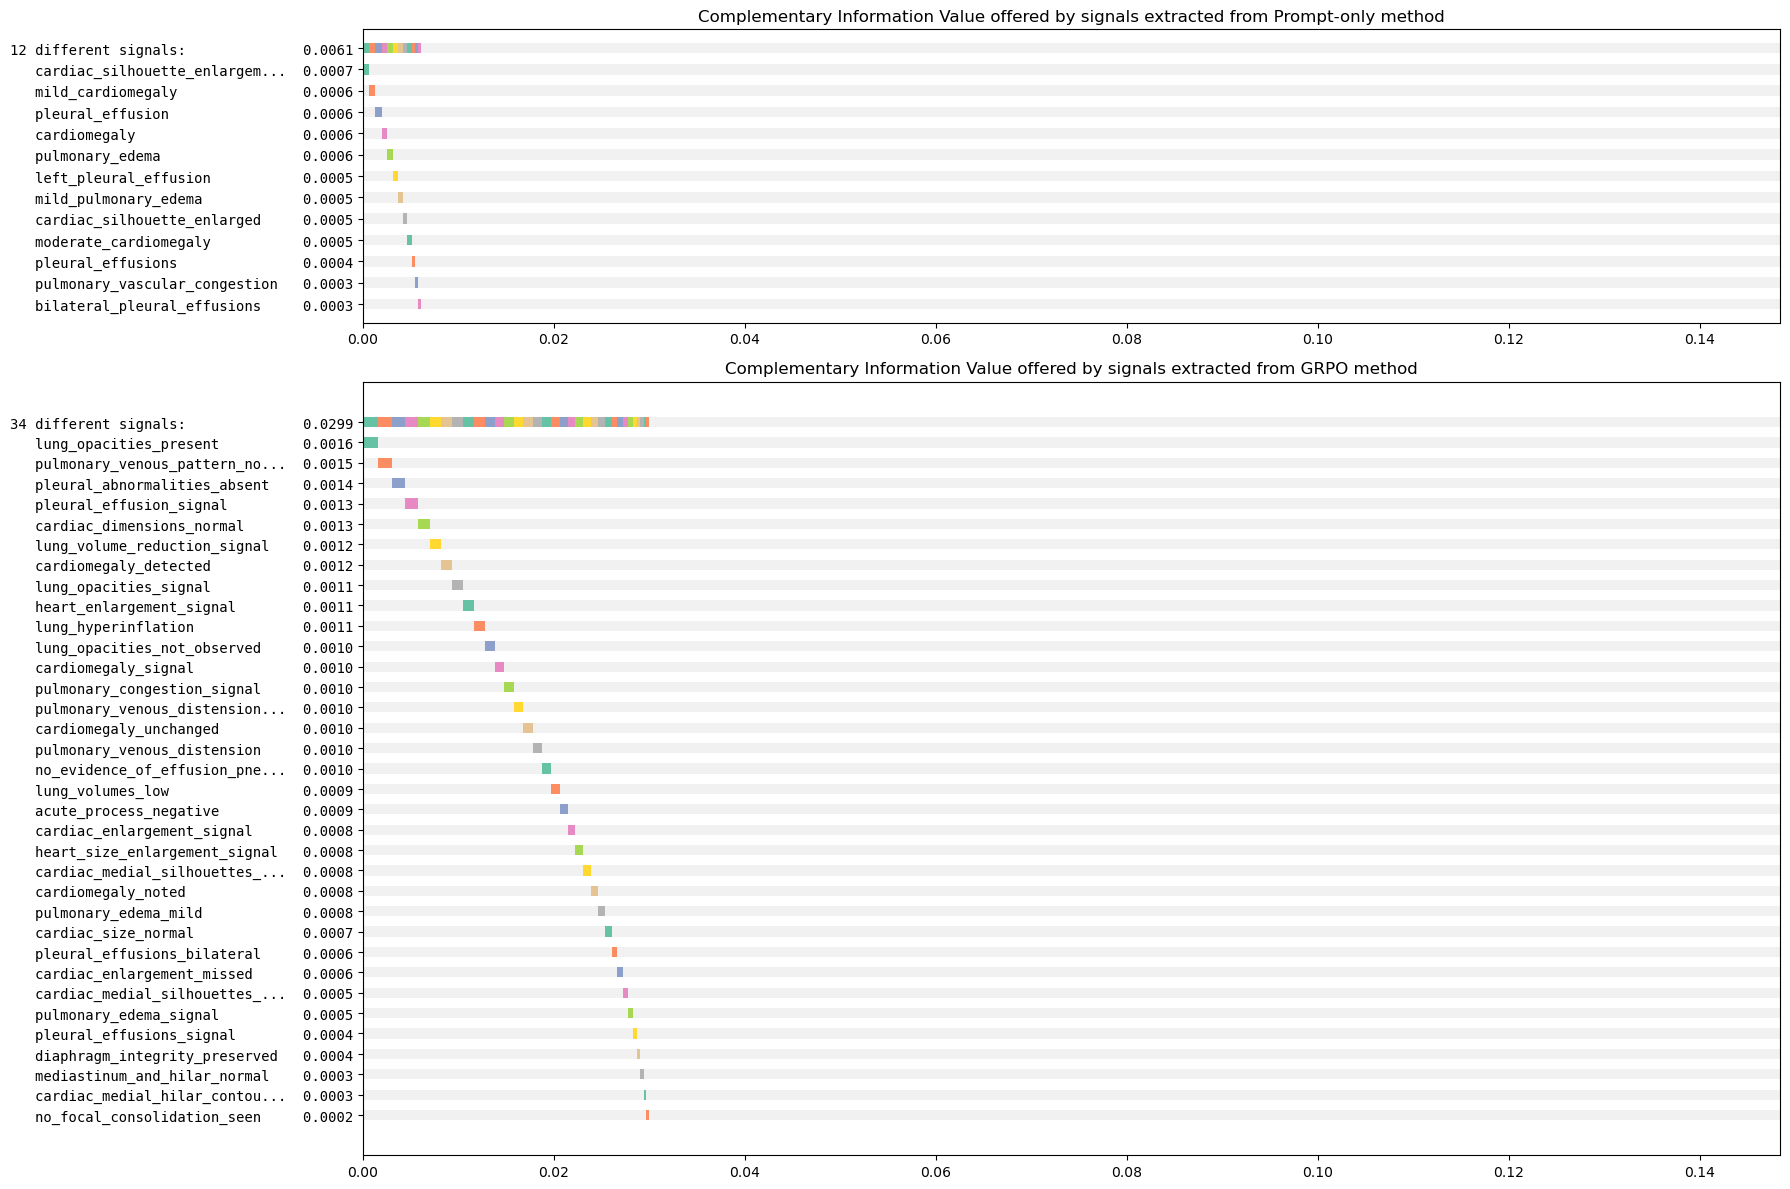

In [93]:
import matplotlib.pyplot as plt

# Create side-by-side subplots for the two methods
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 1, height_ratios=[0.55, 1.45])
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

import numpy as np
from matplotlib.patches import Patch
# Create waterfall plot for concept information values (transposed)
# fig, ax = plt.subplots(figsize=(16, 8))

import matplotlib.pyplot as plt
import matplotlib as mpl

# Use a qualitative ColorBrewer palette from matplotlib
# We'll use 'Set2' which is easy to distinguish and pleasant for categorical sets.
from cycler import cycler

palette = plt.get_cmap('Set2').colors  # tuple of rgb tuples
mpl.rcParams['axes.prop_cycle'] = cycler(color=palette)



color_map = {
    "grpo_cxr_base": {"color": "skyblue", "label": "Prompt-only"},
    # "grpo_cxr_foundation_cluster_baseline": {"color": "red", "label": "Prompt-based-Cluster"},
    # "grpo_0": {"color": "lightcoral", "label": "GRPO"},
    "grpo_cxr_0": {"color": "purple", "label": "GRPO"}
}

for i, method in enumerate(method_list):
    extst_concepts = result[method]["extst_concepts"]
    concepts_value = result[method]["concepts_value"]

    # Sort concepts_value and extst_concepts by concepts_value (descending)
    sorted_indices = np.argsort(concepts_value)[::-1]
    concepts_value = [concepts_value[i] for i in sorted_indices][1:]
    extst_concepts = [extst_concepts[i] for i in sorted_indices][1:]

    # Prepare data for waterfall plot
    y_pos = range(len(concepts_value) + 1)
    total_value = sum(concepts_value)
    cumulative = np.cumsum([0] + concepts_value)

    for j in range(len(concepts_value) + 1):
        axes[i].barh(j, 1, alpha=0.9, color="#f0f0f0", height=0.5)

    # Adjust bar height to reduce padding between bars by setting a smaller 'height'
    for j, (concept, value) in enumerate(zip(extst_concepts, concepts_value)):
        axes[i].barh(0, value, left=cumulative[j], alpha=1, color=palette[j % len(palette)], height=0.5)
    # Plot bars horizontally
    for j, (concept, value) in enumerate(zip(extst_concepts, concepts_value)):
        axes[i].barh(j + 1, value, left=cumulative[j], alpha=1, color=palette[j % len(palette)], height=0.5)

    # Plot cumulative line
    # ax.plot(cumulative[1:], y_pos, 'ro-', linewidth=2, markersize=6, color=color_map[method]["color"])

    # Add value labels on points
    # for i, val in enumerate(cumulative[1:]):
    #     concept = extst_concepts[i]
    #     # if method == "grpo_cxr_foundation_cluster_baseline" and concept != "cxr_foundation_pred":
    #     #     concept = summarized_name_from_gemini_map[method][concept]
    #     # elif concept != "cxr_foundation_pred":
    #     if concept != "cxr_foundation_pred":
    #         concept = concept.split("_", 1)[-1]
    #     if method == "dspy_0" and concept == "cxr_foundation_pred":
    #         continue
    #     ax.text(val - 0.05 if method == "grpo_cxr_base" else val + 0.005, i, f'{concept}: {val:.3f}', ha='left', va='center', fontsize=9)

# Formatting
    # axes[i].set_ylabel('Concept Addition Order')
    # axes[i].set_xlabel('Information Value')
    axes[i].set_xlim(0, 1 - result[method]["concepts_value"][0] - info_model[method].no_info_value)
    axes[i].set_title('Waterfall Plot: Cumulative Information Value of Concepts')
    axes[i].grid(True, alpha=0.3)

    # Invert y-axis to make it start from the top
    axes[i].invert_yaxis()
    axes[i].set_yticks(y_pos)
    name_concepts = [c[9:] if len(c[9:]) < 30 else c[9:36] + "..." for c in extst_concepts]
    # Align the concepts (name_concepts) to the left and value to the right by customizing the yticklabels
    # Use a fixed width for the concept label to make the value aligned
    concept_label_width = 30
    axes[i].set_yticklabels(
        [f"{len(concepts_value)} different signals:{total_value:>{concept_label_width - 10}.4f}"] + 
        [f"{name:<{concept_label_width}} {value:>7.4f}" for name, value in zip(name_concepts, concepts_value)],
        fontfamily='monospace'
    )
    # axes[i].set_yticklabels([f"Total: {total_value:.3f}"] + [f'{i}: {value:.3f}' for i, value in zip(name_concepts, concepts_value)])

    axes[i].set_title(f"Complementary Information Value offered by signals extracted from {color_map[method]['label']} method")

    # Add legend using color_map
    # legend_handles = [Patch(color=color_map[method]["color"], label=color_map[method]["label"]) for method in color_map.keys()]
    # ax.legend(handles=legend_handles, title="Method")


plt.tight_layout()
for ax in axes:
    ax.grid(False)
plt.savefig("cxr_foundation_complementary_waterfall.png")
plt.show()

/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x1115bce00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:58: FutureWarning: The provided callable <function mean at 0x1115bce00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users

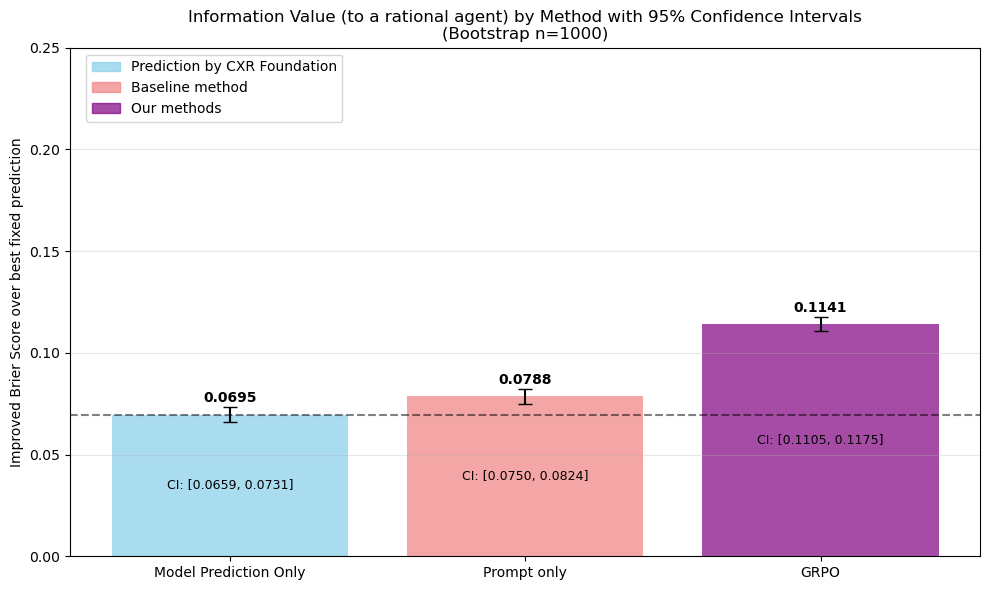

Bootstrap Analysis Summary:
Prompt only:
  Mean: 0.078783
  95% CI: [0.075004, 0.082366]
  CI Width: 0.007362

GRPO:
  Mean: 0.114051
  95% CI: [0.110546, 0.117483]
  CI Width: 0.006938



In [9]:
# Bootstrap analysis for all_compl_value
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Extract all_compl_value data from results
methods = list(result.keys())
method_names = ["Prompt only", "GRPO"]  # Corresponding display names

# Prepare data for bootstrap analysis
bootstrap_results = {}
n_bootstrap = 1000

for i, method in enumerate(["cxr_foundation_pred"] + methods):
    # all_compl_value = result[method]['all_compl_value']
    if method == "cxr_foundation_pred":
        all_compl_value = info_model[methods[0]].complement_info_value(["cxr_foundation_pred"], [], ret_orig_value=True)
    else:
        all_compl_value = info_model[method].complement_info_value(concept_cols[method] + ["cxr_foundation_pred"], [], ret_orig_value=True)
    
    # Bootstrap sampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(all_compl_value, size=len(all_compl_value), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))
    
    # Calculate confidence intervals
    mean_value = np.mean(all_compl_value)
    ci_lower = np.percentile(bootstrap_means, 2.5)
    ci_upper = np.percentile(bootstrap_means, 97.5)
    
    bootstrap_results[method] = {
        'mean': mean_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'bootstrap_means': bootstrap_means
    }

# Create bar chart with confidence intervals
fig, ax = plt.subplots(figsize=(10, 6))

x_pos = np.arange(len(methods) + 1)
means = [bootstrap_results[method]['mean'] for method in ["cxr_foundation_pred"] + methods]
ci_lowers = [bootstrap_results[method]['ci_lower'] for method in ["cxr_foundation_pred"] + methods]
ci_uppers = [bootstrap_results[method]['ci_upper'] for method in ["cxr_foundation_pred"] + methods]

# Calculate error bars
yerr_lower = [means[i] - ci_lowers[i] for i in range(len(means))]
yerr_upper = [ci_uppers[i] - means[i] for i in range(len(means))]

# Create bars with error bars
bars = ax.bar(x_pos, means, yerr=[yerr_lower, yerr_upper], 
              capsize=5, alpha=0.7, 
              color=['skyblue', 'lightcoral', 'purple'])

# Add value labels on bars
for i, (bar, mean_val, ci_low, ci_up) in enumerate(zip(bars, means, ci_lowers, ci_uppers)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (ci_up - mean_val) + 0.001,
            f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            f'CI: [{ci_low:.4f}, {ci_up:.4f}]', ha='center', va='center', 
            fontsize=9, rotation=0)

# Formatting
ax.set_ylabel('Improved Brier Score over best fixed prediction')
ax.set_ylim(0.0, 0.25)
ax.set_title('Information Value (to a rational agent) by Method with 95% Confidence Intervals\n(Bootstrap n=1000)')
ax.set_xticks(x_pos)
ax.set_xticklabels(["Model Prediction Only"] + method_names)
ax.grid(True, alpha=0.3, axis='y')

# Add horizontal line at y=0 for reference
ax.axhline(y=bootstrap_results["cxr_foundation_pred"]["mean"], color='black', linestyle='--', alpha=0.5)

legend_labels = ['Prediction by CXR Foundation', 'Baseline method', 'Our methods']
legend_colors = ['skyblue', 'lightcoral', 'purple']

# Create legend handles
legend_handles = [plt.Rectangle((0,0),1,1, color=color, alpha=0.7) for color in legend_colors[:len(methods)+1]]
legend_labels_filtered = legend_labels[:len(methods)+1]
# Add legend to the last subplot
ax.legend(legend_handles, legend_labels_filtered, loc='upper left', bbox_to_anchor=(0.01, 1))

plt.tight_layout()
plt.savefig("cxr_human_ai_complementary_rational_agent.png")
plt.show()

# Print summary statistics
print("Bootstrap Analysis Summary:")
print("=" * 50)
for i, method in enumerate(methods):
    stats_dict = bootstrap_results[method]
    print(f"{method_names[i]}:")
    print(f"  Mean: {stats_dict['mean']:.6f}")
    print(f"  95% CI: [{stats_dict['ci_lower']:.6f}, {stats_dict['ci_upper']:.6f}]")
    print(f"  CI Width: {stats_dict['ci_upper'] - stats_dict['ci_lower']:.6f}")
    print()


In [10]:
merged_data[method_list[0]]
rational_decision = info_model[method_list[0]].rational_decision(["concepts_bilateral_pleural_effusions", "cxr_foundation_pred"], [1, 0.6])
rational_decision

/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:25: FutureWarning: The provided callable <function mean at 0x1115bce00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()


0.52

In [11]:
pd.DataFrame(merged_data[method_list[0]][concept_cols[method_list[0]] + ["cxr_foundation_pred"]].values, columns=concept_cols[method_list[0]] + ["cxr_foundation_pred"])

,concepts_bilateral_pleural_effusions,concepts_cardiac_enlargement,concepts_cardiac_silhouette_enlarged,concepts_cardiac_silhouette_enlargement,concepts_cardiomegaly,concepts_left_pleural_effusion,concepts_mild_cardiomegaly,concepts_mild_interstitial_edema,concepts_mild_pulmonary_edema,concepts_moderate_cardiomegaly,concepts_pleural_effusion,concepts_pleural_effusions,concepts_pulmonary_congestion,concepts_pulmonary_edema,concepts_pulmonary_vascular_congestion,concepts_pulmonary_vascular_engorgement,concepts_right_pleural_effusion,concepts_severe_cardiomegaly,cxr_foundation_pred
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.7
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1
12143,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12144,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8


In [34]:
merged_data[method_list[0]].loc[:, concept_cols[method_list[0]]]

,concepts_bilateral_pleural_effusions,concepts_cardiac_enlargement,concepts_cardiac_silhouette_enlarged,concepts_cardiac_silhouette_enlargement,concepts_cardiomegaly,concepts_left_pleural_effusion,concepts_mild_cardiomegaly,concepts_mild_interstitial_edema,concepts_mild_pulmonary_edema,concepts_moderate_cardiomegaly,concepts_pleural_effusion,concepts_pleural_effusions,concepts_pulmonary_congestion,concepts_pulmonary_edema,concepts_pulmonary_vascular_congestion,concepts_pulmonary_vascular_engorgement,concepts_right_pleural_effusion,concepts_severe_cardiomegaly
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12141,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12142,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12143,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12144,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [35]:
merged_data[method_list[0]].loc[:, "rational_decision"] = info_model[method_list[0]].rational_decision(concept_cols[method_list[0]] + ["cxr_foundation_pred"], merged_data[method_list[0]][concept_cols[method_list[0]] + ["cxr_foundation_pred"]].values)
merged_data[method_list[1]].loc[:, "rational_decision"] = info_model[method_list[1]].rational_decision(concept_cols[method_list[1]] + ["cxr_foundation_pred"], merged_data[method_list[1]][concept_cols[method_list[1]] + ["cxr_foundation_pred"]].values)
comparison_data = pd.concat([merged_data[method_list[0]][["abnormal_stratified", "cxr_foundation_pred", "rational_decision"]], merged_data[method_list[1]][["rational_decision"]]], axis=1)
comparison_data.columns = ["abnormal_stratified", "cxr_foundation_pred", "grpo_cxr_base", "grpo_cxr_0"]
comparison_data.loc[:, "grpo_cxr_base_accuracy"] = comparison_data.loc[:, ["grpo_cxr_base", "abnormal_stratified"]].apply(lambda x: (x[0] > 0.5) == x[1], axis=1)
comparison_data.loc[:, "grpo_cxr_0_accuracy"] = comparison_data.loc[:, ["grpo_cxr_0", "abnormal_stratified"]].apply(lambda x: (x[0] > 0.5) == x[1], axis=1)
comparison_data.loc[:, "base_concepts"] = merged_data[method_list[0]].loc[:, concept_cols[method_list[0]]].apply(lambda x: [concept for concept in concept_cols[method_list[0]] if concept != "cxr_foundation_pred" and x[concept] == 1], axis=1)
comparison_data.loc[:, "0_concepts"] = merged_data[method_list[1]].loc[:, concept_cols[method_list[1]]].apply(lambda x: [concept for concept in concept_cols[method_list[1]] if concept != "cxr_foundation_pred" and x[concept] == 1], axis=1)
comparison_data.loc[comparison_data.loc[:, "grpo_cxr_base_accuracy"] != comparison_data.loc[:, "grpo_cxr_0_accuracy"], :].to_csv("comparison_data.csv")
comparison_data.loc[comparison_data.loc[:, "grpo_cxr_base_accuracy"] != comparison_data.loc[:, "grpo_cxr_0_accuracy"], :]

/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:25: FutureWarning: The provided callable <function mean at 0x1115bce00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/Users/guoziyang/Documents/Documents - GuoZiYang的MacBook Pro/info-value-toolkit/decision_infovalue/rational_agent/_rational_agent.py:25: FutureWarning: The provided callable <function mean at 0x1115bce00> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped = use_data[signals + [gt]].groupby(signals, dropna=False).agg(calibrated_action=(gt, agg_func)).reset_index()
/var/f

,abnormal_stratified,cxr_foundation_pred,grpo_cxr_base,grpo_cxr_0,grpo_cxr_base_accuracy,grpo_cxr_0_accuracy,base_concepts,0_concepts
7,True,0.3,0.352941,1.000000,False,True,[],"[concepts_cardiac_medial_silhouettes_stable, c..."
12,False,0.4,0.666667,0.000000,False,True,[concepts_pleural_effusion],"[concepts_cardiac_enlargement_missed, concepts..."
33,True,0.6,0.760000,0.500000,True,False,"[concepts_cardiomegaly, concepts_pulmonary_edema]","[concepts_cardiomegaly_signal, concepts_pulmon..."
39,True,0.4,0.463636,1.000000,False,True,[],"[concepts_lung_opacities_present, concepts_ple..."
52,False,0.4,0.625000,0.500000,False,True,[concepts_mild_cardiomegaly],"[concepts_heart_enlargement_signal, concepts_p..."
...,...,...,...,...,...,...,...,...
12088,False,0.5,0.571429,0.000000,False,True,[concepts_cardiac_silhouette_enlarged],"[concepts_aortic_calciﬁcation_signal, concepts..."
12093,True,0.2,0.333333,1.000000,False,True,[concepts_cardiomegaly],"[concepts_aortic_calciﬁcation_signal, concepts..."
12098,False,0.5,0.428571,0.609756,True,False,[concepts_cardiac_enlargement],[concepts_cardiac_enlargement_signal]
12123,False,0.6,0.566978,0.000000,False,True,[],[concepts_lung_volumes_low]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for method in method_list:

    calibrate_data = merged_data[method].copy()
    # Calculate multicalibrated error of cxr_foundation_pred w.r.t. each concept
    concept_columns = concept_cols[method]
    multicalib_errors = []
    concept_names = []

    for concept in concept_columns:
        # Bin by concept (0/1)

        def multi_ece(val):
            mask = calibrate_data[concept] == val
            if mask.sum() == 0:
                return 0
            # Brier error for this group
            y_true = calibrate_data.loc[mask, "abnormal_stratified"]
            y_pred = calibrate_data.loc[mask, "cxr_foundation_pred"]
            temp_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
            temp_df.loc[:, "binned_pred"] = pd.cut(y_pred, bins=np.arange(0, 1.01, 0.1), include_lowest=True, right=False, labels=False)
            temp_df_group = temp_df.groupby("binned_pred").agg({"y_true": "mean"}).reset_index()
            temp_df = pd.merge(temp_df, temp_df_group, on="binned_pred", how="left")
            temp_df.loc[:, "ece"] = np.abs(temp_df["y_pred"] - temp_df["y_true_y"])
            ece = np.mean(temp_df["ece"])
            return ece
        multicalib_errors.append(np.mean([multi_ece(val) for val in [0, 1]]))
        concept_names.append(f"{concept}")
    # Rank the concepts ascendingly by their multicalibrated error
    sorted_indices = np.argsort(multicalib_errors)[::-1]
    concept_names = [concept_names[i].split("_", 1)[1] for i in sorted_indices]
    multicalib_errors = [multicalib_errors[i] for i in sorted_indices]

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(concept_names, multicalib_errors, color='skyblue')
    plt.ylabel("Brier Score (Multicalibrated Error)")
    plt.title("Multicalibrated Error of CXR Foundation Prediction w.r.t. Concepts")
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
plt.show()

In [ ]:
merged_data["dspy_0"]

In [ ]:
train_xgb_data

In [89]:
# method_list = ["topicgpt_0", "dspy_0","dpo_0",  "grpo_0", "dspy_1"]

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def train_logistic_regression(train_concept_data, concept_cols):
    logistic_regression = LogisticRegression(random_state=42, max_iter=200)
    logistic_regression.fit(train_concept_data[concept_cols], train_concept_data["abnormal_stratified"])
    return logistic_regression

def train_xgboost(train_concept_data, concept_cols):
    params = {'lambda': 5.08745375747522, 'alpha': 1.3840557746026854, 'colsample_bytree': 1, 'subsample': 0.7, 
           'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 9}
    xgboost = xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='rmse',
        **params
    )
    xgboost.fit(train_concept_data[concept_cols], train_concept_data["abnormal_stratified"])
    return xgboost

use_model = "logistic_regression"

# train_data, test_data = train_test_split(merged_data[method_list[0]], test_size=0.2, random_state=42, stratify=merged_data[method_list[0]]["abnormal_stratified"])
train_data, test_data = merged_data[method_list[0]], merged_data[method_list[0]]

for method in method_list:
    train_xgb_data, test_xgb_data = merged_data[method].iloc[train_data.index], merged_data[method].iloc[test_data.index]


    if use_model == "xgboost":
        xgboost = train_xgboost(train_xgb_data, concept_cols[method] + ["cxr_foundation_pred"])
        train_prediction = xgboost.predict_proba(train_xgb_data[concept_cols[method] + ["cxr_foundation_pred"]])[:, 1]
        
        # Print XGBoost feature importance (coefficients)
        feature_names = concept_cols[method] + ["cxr_foundation_pred"]
        feature_importance = xgboost.feature_importances_
        print(f"Number of non-zero importance features: {np.sum(feature_importance > 2.5e-3)}")
        train_brier_score = np.mean(1 - (train_prediction - train_xgb_data["abnormal_stratified"]) ** 2)
        train_accuracy = np.mean((train_prediction > 0.5) == train_xgb_data["abnormal_stratified"])
        print(f"{method} Train Brier Score: {train_brier_score}, Train Accuracy: {train_accuracy}")
        test_data.loc[:, f"{method}_pred"] = xgboost.predict_proba(test_xgb_data[concept_cols[method] + ["cxr_foundation_pred"]])[:, 1]
        test_brier_score = np.mean(1 - (test_data[f"{method}_pred"] - test_data["abnormal_stratified"]) ** 2)
        test_accuracy = np.mean((test_data[f"{method}_pred"] > 0.5) == test_data["abnormal_stratified"])
        print(f"{method} Test Brier Score: {test_brier_score}, Test Accuracy: {test_accuracy}")
        
    elif use_model == "logistic_regression":
        logistic_regression = train_logistic_regression(train_xgb_data, concept_cols[method] + ["cxr_foundation_pred"])
        train_prediction = logistic_regression.predict_proba(train_xgb_data[concept_cols[method] + ["cxr_foundation_pred"]])[:, 1]
        non_zero_coef_count = np.sum(np.abs(logistic_regression.coef_) > 2.5e-3)
        print(f"Number of non-zero coefficients: {non_zero_coef_count}")
        # train_concept_data[f"{method}_pred"] = train_prediction
        # test_concept_data[f"{method}_pred"] = logistic_regression.predict_proba(test_xgb_data[concept_cols[method] + ["cxr_foundation_pred"]])[:, 1]
        train_brier_score = np.mean(1 - (train_prediction - train_xgb_data["abnormal_stratified"]) ** 2)
        print(f"{method} Train Brier Score: {train_brier_score}")
        test_data.loc[:, f"{method}_pred"] = logistic_regression.predict_proba(test_xgb_data[concept_cols[method] + ["cxr_foundation_pred"]])[:, 1]
        test_brier_score = np.mean(1 - (test_data[f"{method}_pred"] - test_data["abnormal_stratified"]) ** 2)
        print(f"{method} Test Brier Score: {test_brier_score}")
        

Number of non-zero coefficients: 13
grpo_cxr_base Train Brier Score: 0.8503881545638108
grpo_cxr_base Test Brier Score: 0.8503881545638108
Number of non-zero coefficients: 34
grpo_cxr_0 Train Brier Score: 0.8533402498823005
grpo_cxr_0 Test Brier Score: 0.8533402498823005


In [ ]:
use_concept = "concepts_no_pleural_effusion"
calibrate_data = test_data[["abnormal_stratified", "cxr_foundation_pred"] + [f"{method}_pred" for method in method_list]].copy()
for method in method_list:
    calibrate_data.loc[:, f"{method}_{use_concept}"] = merged_data[method][use_concept]
import matplotlib.pyplot as plt
import numpy as np

# Bin the cxr_foundation_pred into bins of size 0.1
bins = np.arange(0, 1.01, 0.1)
bin_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

binned = pd.cut(
    calibrate_data["cxr_foundation_pred"], 
    bins=bins, 
    include_lowest=True, 
    right=True, 
    labels=bin_labels
)

bin_probs = calibrate_data.groupby(binned)["abnormal_stratified"].mean()
bin_counts = calibrate_data.groupby(binned)["abnormal_stratified"].count()


# binned_calibrated = pd.cut(
#     calibrate_data[f"{method_list[0]}_pred"], 
#     bins=bins, 
#     include_lowest=True, 
#     right=False, 
#     labels=bin_labels
# )

# bin_probs_calibrated = calibrate_data.groupby(binned_calibrated)["abnormal_stratified"].mean()
# bin_counts_calibrated = calibrate_data.groupby(binned_calibrated)["abnormal_stratified"].count()

plt.figure(figsize=(8, 4))
plt.bar(bin_labels, bin_probs, color='b', alpha=0.7)
# plt.bar(bin_labels, bin_probs_calibrated, color='r', alpha=0.7)
plt.xlabel('CXR Foundation Prediction (Binned, width=0.1)')
plt.ylabel('Probability of Abnormal Stratified')
plt.title('Probability of abnormal_stratified vs. cxr_foundation_pred')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.tight_layout()
# Optionally show bin counts
for i, (label, prob, count) in enumerate(zip(bin_labels, bin_probs, bin_counts)):
    plt.text(i, prob + 0.01, f"n={count}", ha='center', fontsize=8, color='gray')

fig, axs = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

concept_values = [0, 1]
concept_names = ["Without Concept", "With Concept"]
for idx, concept_val in enumerate(concept_values):
    stratified = calibrate_data[calibrate_data[f"{method_list[0]}_{use_concept}"] == concept_val]
    strat_binned = pd.cut(
        stratified["cxr_foundation_pred"], 
        bins=bins, 
        include_lowest=True, 
        right=True, 
        labels=bin_labels
    )
    strat_bin_probs = stratified.groupby(strat_binned)["abnormal_stratified"].mean()
    strat_bin_counts = stratified.groupby(strat_binned)["abnormal_stratified"].count()

    strat_binned_calibrated = pd.cut(
        stratified[f"{method_list[0]}_pred"], 
        bins=bins, 
        include_lowest=True, 
        right=True, 
        labels=bin_labels
    )
    strat_bin_calibrated_probs = stratified.groupby(strat_binned_calibrated)["abnormal_stratified"].mean()
    strat_bin_calibrated_counts = stratified.groupby(strat_binned_calibrated)["abnormal_stratified"].count()

    axs[idx].bar(bin_labels, strat_bin_probs, color='b', alpha=0.7)
    # axs[idx].bar(bin_labels, strat_bin_calibrated_probs, color='r', alpha=0.7)
    axs[idx].set_xlabel('CXR Foundation Prediction (Binned, width=0.1)')
    axs[idx].set_title(f"{concept_names[idx]} ({use_concept})")
    axs[idx].set_xticklabels(bin_labels, rotation=45)
    axs[idx].grid(True, alpha=0.5)
    # Show bin counts
    for i, (label, prob, calibrated_prob, count, calibrated_count) in enumerate(zip(bin_labels, strat_bin_probs, strat_bin_calibrated_probs, strat_bin_counts, strat_bin_calibrated_counts)):
        if not np.isnan(prob):
            axs[idx].text(i, prob + 0.01, f"n={count}", ha='center', fontsize=8, color='gray')
            # axs[idx].text(i, calibrated_prob + 0.01, f"n={calibrated_count}", ha='center', fontsize=8, color='red')
axs[0].set_ylabel('Probability of Abnormal Stratified')
fig.suptitle('Calibration of cxr_foundation_pred Stratified by Concept ({})'.format(use_concept))
fig.tight_layout(rect=[0, 0.03, 1, 0.95])


fig, axs = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

concept_values = [0, 1]
concept_names = ["Without Concept", "With Concept"]
for idx, concept_val in enumerate(concept_values):
    stratified = calibrate_data[calibrate_data[f"{method_list[1]}_{use_concept}"] == concept_val]
    strat_binned = pd.cut(
        stratified["cxr_foundation_pred"], 
        bins=bins, 
        include_lowest=True, 
        right=True, 
        labels=bin_labels
    )
    strat_bin_probs = stratified.groupby(strat_binned)["abnormal_stratified"].mean()
    strat_bin_counts = stratified.groupby(strat_binned)["abnormal_stratified"].count()

    strat_binned_calibrated = pd.cut(
        stratified[f"{method_list[1]}_pred"], 
        bins=bins, 
        include_lowest=True, 
        right=True, 
        labels=bin_labels
    )
    strat_bin_calibrated_probs = stratified.groupby(strat_binned_calibrated)["abnormal_stratified"].mean()
    strat_bin_calibrated_counts = stratified.groupby(strat_binned_calibrated)["abnormal_stratified"].count()

    axs[idx].bar(bin_labels, strat_bin_probs, color='b', alpha=0.7)
    # axs[idx].bar(bin_labels, strat_bin_calibrated_probs, color='r', alpha=0.7)
    axs[idx].set_xlabel('CXR Foundation Prediction (Binned, width=0.1)')
    axs[idx].set_title(f"{concept_names[idx]} ({use_concept})")
    axs[idx].set_xticklabels(bin_labels, rotation=45)
    axs[idx].grid(True, alpha=0.5)
    # Show bin counts
    for i, (label, prob, calibrated_prob, count, calibrated_count) in enumerate(zip(bin_labels, strat_bin_probs, strat_bin_calibrated_probs, strat_bin_counts, strat_bin_calibrated_counts)):
        if not np.isnan(prob):
            axs[idx].text(i, prob + 0.01, f"n={count}", ha='center', fontsize=8, color='gray')
            # axs[idx].text(i, calibrated_prob + 0.01, f"n={calibrated_count}", ha='center', fontsize=8, color='red')
axs[0].set_ylabel('Probability of Abnormal Stratified')
fig.suptitle('Calibration of cxr_foundation_pred Stratified by Concept ({})'.format(use_concept))
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


In [ ]:
test_data

In [ ]:
from scipy.stats import bootstrap

def brier_score(pred_proba, label):
    return 1 - (pred_proba - label) ** 2

def threshold_accuracy(pred_proba, label):
    return (pred_proba > 0.5).astype(int) == label


def score_FP_FN(pred_proba, label, l=0.5):
    threshold = l / (1 + l)
    return (pred_proba > threshold).astype(int) == label

def calibration_error(pred_proba, label):
    temp_df = pd.DataFrame({"pred_proba": np.round(pred_proba, 1), "label": label})
    temp_df_group = temp_df.groupby("pred_proba").agg({"label": "mean"}).reset_index()
    temp_df = pd.merge(temp_df, temp_df_group, on="pred_proba", how="left")
    return np.abs(temp_df["pred_proba"] - temp_df["label_y"])

def multicalibration_error(pred_proba, signals, label):
    temp_df = pd.DataFrame({"pred_proba": np.round(pred_proba, 1), "signals": signals, "label": label})
    # temp_df.loc[:, "signals"] = temp_df["signals"].apply(lambda x: eval(x))
    # temp_df.loc[:, "signals"] = temp_df["signals"].apply(lambda x: [t["name"] if isinstance(t, dict) else t for t in x])
    # temp_df.loc[:, "signals"] = temp_df["signals"].apply(lambda x: str(x))
    temp_df_group = temp_df.groupby(["pred_proba", "signals"]).agg({"label": "mean"}).reset_index()
    temp_df = pd.merge(temp_df, temp_df_group, on=["pred_proba", "signals"], how="left")
    return np.abs(temp_df["pred_proba"] - temp_df["label_y"])


# Calculate all metrics for each method
diagnosis_cols = ['cxr_foundation_pred'] + [f"{method}_pred" for method in method_list]
# concept_cols = [None, 'dpo_0_concepts', 'dspy_0_concepts', 'grpo_0_concepts']

# Calculate metrics
brier_scores = []
accuracies = []
FP_FN_05_scores = []
FP_FN_02_scores = []
FP_FN_2_scores = []
FP_FN_5_scores = []
calibration_errors = []
multicalibration_errors = []

for diag_col in diagnosis_cols:
    # Brier score
    brier = brier_score(test_data[diag_col], test_data["abnormal_stratified"].astype(int))
    brier_scores.append(bootstrap((brier,), np.mean, confidence_level=0.95, random_state=42))
    
    # Accuracy
    acc = threshold_accuracy(test_data[diag_col], test_data["abnormal_stratified"].astype(int))
    accuracies.append(bootstrap((acc,), np.mean, confidence_level=0.95, random_state=42))


    # 0.5 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=0.5)
    FP_FN_05_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    # 0.2 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=0.2)
    FP_FN_02_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    # 2 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=2)
    FP_FN_2_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    # 5 FP/FN
    FP_FN = score_FP_FN(test_data[diag_col], test_data["abnormal_stratified"].astype(int), l=5)
    FP_FN_5_scores.append(bootstrap((FP_FN,), np.mean, confidence_level=0.95, random_state=42))
    
    # Calibration error
    # cal_err = calibration_error(test_data[diag_col], test_data["abnormal_stratified"].astype(int))
    # calibration_errors.append(bootstrap((cal_err,), np.mean, confidence_level=0.95, random_state=42))
    
    # if concept_col is not None:
    #     # Multicalibration error (using abnormal_stratified as signal)
    # if diag_col == "cxr_foundation_pred":
    #     multical_err = calibration_error(test_data[diag_col], test_data["abnormal_stratified"].astype(int))
    # else:
    #     multical_err = multicalibration_error(test_data[diag_col], test_data["concepts_no_pleural_effusion"], 
    #                                         test_data["abnormal_stratified"])
    # multicalibration_errors.append(bootstrap((multical_err,), np.mean, confidence_level=0.95, random_state=42))

In [ ]:
brier_scores

In [ ]:

metrics = [
    ('Brier Score', brier_scores, 'skyblue'),
    ('Accuracy (FP/FN=1)', accuracies, 'lightcoral'),
    ('FP/FN=0.5', FP_FN_05_scores, 'purple'),
    ('FP/FN=0.2', FP_FN_02_scores, 'purple'),
    ('FP/FN=2', FP_FN_2_scores, 'purple'),
    ('FP/FN=5', FP_FN_5_scores, 'purple'),
    # ('ECE', calibration_errors, 'lightgreen'),
    # ('Multicalibration Error w.r.t. No Pleural Effusion', multicalibration_errors, 'lightgreen'),

    # ('Multicalibration Error', multicalibration_errors, 'gold')
]

# Create subplot with 4 metrics
fig, axes = plt.subplots(len(metrics)//2, 2, figsize=(15, 15))
axes = axes.flatten()
methods = ['CXR foundations \nprediction','XGBoost model with \n Prompt-based signals', 'XGBoost model with +\n GRPO signals']

for i, (metric_name, values, color) in enumerate(metrics):
    ax = axes[i]
    colors = ['skyblue','lightcoral', 'purple']
    bars = ax.bar(methods, [np.mean(v.bootstrap_distribution) for v in values], alpha=0.7, 
                  color=colors[:len(methods)], capsize=5, 
                  yerr=([np.mean(v.bootstrap_distribution) - v.confidence_interval.low for v in values], [v.confidence_interval.high - np.mean(v.bootstrap_distribution) for v in values]))
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if metric_name == 'Accuracy (Threshold=0.5)':
            ax.text(bar.get_x() + bar.get_width()/2., height + max([np.mean(v.bootstrap_distribution) for v in values]) * 0.01,
                    f'{np.mean(value.bootstrap_distribution):.1%}', ha='center', va='bottom', fontsize=10)
        else:
            ax.text(bar.get_x() + bar.get_width()/2., height + max([np.mean(v.bootstrap_distribution) for v in values]) * 0.01,
                    f'{np.mean(value.bootstrap_distribution):.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel(metric_name)
    # ax.set_xlabel('Method')
    ax.set_title(f'{metric_name}')
    ax.grid(True, alpha=0.3, axis='y')
    # Set y-axis to percentage
    if metric_name == 'Accuracy (Threshold=0.5)':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    if metric_name == 'Brier Score':
        ax.set_ylim(0.75, 1)
    elif metric_name == 'ECE' or metric_name == 'Multicalibration Error w.r.t. No Pleural Effusion':
        ax.set_ylim(0, 0.1)
    else:
        ax.set_ylim(0.5, 1)
    
    # Add legend for the colors
    legend_labels = ['Prediction by CXR Foundation', 'Baseline method', 'Our methods']
    legend_colors = ['skyblue', 'lightcoral', 'purple']
    
    # Create legend handles
    legend_handles = [plt.Rectangle((0,0),1,1, color=color, alpha=0.7) for color in legend_colors[:len(methods)]]
    legend_labels_filtered = legend_labels[:len(methods)]
    
    # Add legend to the last subplot
    ax.legend(legend_handles, legend_labels_filtered, loc='upper left', bbox_to_anchor=(0.01, 1))
    # axes[1].legend(legend_handles, legend_labels_filtered, loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("cxr_foundation_complementary_signals.png")
plt.show()

In [ ]:
# Calculate average number of concepts per instance
method_list = ["dspy_0","grpo_0"]
avg_concepts_per_instance = {}

for method in method_list:
    avg_concepts_per_instance[method] = test_concept_data[f"{method}_concepts"].apply(lambda x: len(eval(x)) if isinstance(x, str) else 0 if np.isnan(x) else len(x)).mean()
    print(f"{method} Average number of concepts per instance: {avg_concepts_per_instance[method]:.2f}")

# Plot bar chart for average concepts per instance
fig, ax = plt.subplots(figsize=(10, 6))

methods = list(avg_concepts_per_instance.keys())
values = list(avg_concepts_per_instance.values())

bars = ax.bar(methods, values, alpha=0.7, color='skyblue')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(values) * 0.01,
            f'{value:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Average Number of Concepts per Instance')
ax.set_xlabel('Method')
ax.set_title('Average Number of Concepts per Instance by Method')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



In [ ]:
data, metadata = decision_infovalue.get_dataset("cxr")
topics_df = pd.read_json("data/output/sample/generation_1.jsonl", lines=True)
topics_df.loc[:, "concepts"] = topics_df["responses"].apply(lambda x: list(set([t.strip() for t in x.split("\n") if t.strip() != "None"])))
topics_list = [topic for sublist in topics_df["concepts"].tolist() for topic in sublist]
small_topics = [topic for topic, count in Counter(topics_list).items() if count < len(data) * 0.01]
topics_df.loc[:, "concepts"] = topics_df["concepts"].apply(lambda x: list(set(sorted([t for t in x if t not in small_topics and t != "None"]))))
topics_df.loc[:, "ID"] = topics_df.index
dummy_merged_data = pd.get_dummies(topics_df.explode("concepts")[["concepts", "ID"]], columns=["concepts"], prefix="concepts")
concept_cols = [col for col in dummy_merged_data.columns if "concepts" in col]
dummy_merged_data = dummy_merged_data.groupby("ID").agg({col: "sum" for col in concept_cols}).reset_index()

merged_df = pd.concat([data, dummy_merged_data], axis=1)
test_topics_df = merged_df.drop(train_index).reset_index(drop=True)
# merged_df = merged_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
info_model = decision_infovalue.DecisionInfoModel(test_topics_df, "abnormal_stratified", 
                                     signals=concept_cols, 
                                     binning_method=None)
print(info_model.complement_info_value(concept_cols, [], ret_std=True))
extst_concepts = []
concepts_value = []
for round in range(len(concept_cols)):
    additional_info_value = [info_model.complement_info_value([con], extst_concepts) if con not in extst_concepts else -np.inf for con in concept_cols]
    extst_concepts.append(concept_cols[np.argmax(additional_info_value)])
    concepts_value.append(np.max(additional_info_value) / (1 - info_model.no_info_value))
extst_concepts, concepts_value

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Create waterfall plot for concept information values (transposed)
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data for waterfall plot
y_pos = range(len(concepts_value))
cumulative = np.cumsum([0] + concepts_value)

# Plot bars horizontally
for i, (concept, value) in enumerate(zip(extst_concepts, concepts_value)):
    ax.barh(i, value, left=cumulative[i], alpha=0.7)

# Plot cumulative line
ax.plot(cumulative[1:], y_pos, 'ro-', linewidth=2, markersize=6)

# Formatting
ax.set_ylabel('Concept Addition Order')
ax.set_xlabel('Information Value')
ax.set_xlim(0, 1)
ax.set_title('Waterfall Plot: Cumulative Information Value of Concepts')
ax.grid(True, alpha=0.3)

# Invert y-axis to make it start from the top
ax.invert_yaxis()

# Add value labels on points
for i, val in enumerate(cumulative[1:]):
    ax.text(val + 0.0005, i, f'{val:.4f}', ha='left', va='center', fontsize=9)

plt.yticks(y_pos, [f'Concept {i+1}' for i in y_pos])
plt.tight_layout()
plt.show()


# Information Model

In [ ]:
info_model = decision_infovalue.DecisionInfoModel(data, metadata["target_name"], 
                                     signals=["diagnosis","densenet121_pred","inception_v3_pred","swin_b_pred","resnet50_pred","vit_b_16_pred"], 
                                     scoring_rule="brier",
                                     fit_test_ratio=0.8,
                                     overfit_tolerance=0.1)

In [ ]:
info_model.all_breaks

# Global human-complementary information value in each AI model

In [ ]:
from scipy import stats

models = ["vit_b_16_pred", "densenet121_pred", "inception_v3_pred", "swin_b_pred", "resnet50_pred"]
values = []
stds = []

for model in models:
    value, std = info_model.complement_info_value(model, "diagnosis", constraint_rational_agent="linear", ret_std=True)
    values.append(value)
    stds.append(std)

ci_errors = np.array([[std * stats.t.ppf((1 + 0.95) / 2, len(data) - 1), std * stats.t.ppf((1 + 0.95) / 2, len(data) - 1)] for value, std in zip(values, stds)]).T

plt.figure(figsize=(10, 6))
plt.bar(models, values, yerr=ci_errors, capsize=5)
plt.xticks(rotation=45)
plt.ylabel('Human-complementary information value')
plt.title('Human-complementary information value of different models with 95% CI')
plt.tight_layout()
# info_model.complement_info_value("densenet121_pred", "diagnosis", 0.95)
# info_model.complement_info_value("inception_v3_pred", "diagnosis", 0.95)
# info_model.complement_info_value("swin_b_pred", "diagnosis", 0.95)
# info_model.complement_info_value("resnet50_pred", "diagnosis", 0.95)

# Robust analysis on a grid of V-shaped scoring rules

In [ ]:
# test_model = decision_infovalue.DecisionInfoModel(data, metadata["target_name"], 
#                                      signals=["diagnosis","densenet121_pred","inception_v3_pred","swin_b_pred","resnet50_pred","vit_b_16_pred"], 
#                                      scoring_rule="v_shaped_0.5",
#                                      fit_test_ratio=0.8,
#                                      overfit_tolerance=0.1)
# test_model.complement_info_value("vit_b_16_pred", "diagnosis")
# # test_model.complement_info_value("inception_v3_pred", "diagnosis")

In [ ]:
# grid_size = 100
# model_pair_diffs = np.zeros((len(models), len(models), grid_size))
# model_pair_kinks = np.zeros((len(models), len(models), grid_size))
# for model in models:
#     for compare_model in models:
#         model_pair_diffs[models.index(model), models.index(compare_model)], \
#         model_pair_kinks[models.index(model), models.index(compare_model)] = \
#             info_model.robust_analysis_on_v_shaped_scoring_rule(model, compare_model, 
#                                                                 base_signals=["diagnosis"], 
#                                                                 ret_diff=True, grid_size=grid_size)


In [ ]:

# # plt.figure(figsize=(10, 6))
# fig, axes = plt.subplots(len(models), len(models), layout='constrained', sharey=True)

# for i, model in enumerate(models):
#     for j, compare_model in enumerate(models):
#         axes[i, j].plot(model_pair_kinks[i,j], model_pair_diffs[i,j])
#         axes[i, j].axhline(y=0, color='r', alpha=1)
#         if i == len(models) - 1:
#             axes[i, j].set_xlabel('Kinks')
#         if i == 0:
#             axes[i, j].set_title(f'{compare_model}', fontsize=6)
#         if i != len(models) - 1:
#             axes[i, j].set_xticks([])
#         if j == 0:
#             axes[i, j].set_ylabel(f'{model}', fontsize=6)

# # plt.xlabel('Kink position')
# # plt.ylabel('Difference in complementary information value')
# plt.suptitle('Difference in complementary information value')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.subplots_adjust(wspace=0, hspace=0)

# Information Value of Concept Induction on Textual Reports

In [ ]:
cxr_study_list = pd.read_csv("./cxr-study-list.csv")
data_with_report = pd.merge(data, cxr_study_list, on="study_id", how="left")
# Read text reports from path_x
# data_with_report['report_text'] = data_with_report['path'].apply(lambda x: open(x).read() if pd.notna(x) else '')

data_with_report.head()

In [ ]:
cxr_test_labels = pd.read_csv("./mimic-cxr-2.1.0-test-set-labeled.csv")
pd.merge(data_with_report, cxr_test_labels, on="study_id", how="inner").to_csv("join_cxr_test_labels.csv", index=False)

In [ ]:
data_with_report.loc[:, :].rename(columns={'study_id': 'id', 'path': 'text'})[['id', 'text']].to_json("data/input/sample.jsonl", orient="records", lines=True)

In [ ]:
topics_df = pd.read_json("data/output/sample/refinement.jsonl", lines=True)
topics_df.loc[:, "topics"] = topics_df["refined_responses"].apply(lambda x: list(set([t.strip() for t in x.split("\n") if t.strip() != "None"])))
# topics_df.loc[:, "responses"] = topics_df["responses"].apply(lambda x: "No Findings" if x == "None" else x)
# topics_df.loc[:, "topics"] = topics_df["responses"].apply(lambda x: [t[4:].strip(".") for t in x.split("\n")])
topics_list = [topic for sublist in topics_df["topics"].tolist() for topic in sublist]
small_topics = [topic for topic, count in Counter(topics_list).items() if count < len(data_with_report) * 0.01]
# # Map small topics to "Others" category
topics_df.loc[:, "topics"] = topics_df["topics"].apply(lambda x: str(set(sorted([t for t in x if t not in small_topics and t != "None"]))))
# # Show final counts
# topics_df = topics_df.explode('topics')

# topics_df.loc[topics_df["topics"] == "Cardiomediastinal silhouette (Normal)", "topics"] = "Cardiomegaly (Negative)"
# topics_df.loc[topics_df["topics"] == "Cardiomegaly (Mild)", "topics"] = "Consolidation (Uncertain)"
# topics_df.loc[topics_df["topics"] == "Cardiomegaly (Mildly enlarged)", "topics"] = "Consolidation (Uncertain)"
# topics_df.loc[topics_df["topics"] == "Effusion (Negative)", "topics"] = "Pleural Effusion (Negative)"
# topics_df.loc[topics_df["topics"] == "Heart size (Normal)", "topics"] = "Cardiomegaly (Negative)"
# topics_df.loc[topics_df["topics"] == "Lungs (Clear)", "topics"] = "Lung Clear (Positive)"
# topics_df.loc[topics_df["topics"] == "Lungs clear (Positive)", "topics"] = "Lung Clear (Positive)"
# topics_df.loc[topics_df["topics"] == "Low lung volumes (Positive)", "topics"] = "Lung Volumes (Low)"
# topics_df.loc[topics_df["topics"] == "No acute cardiopulmonary abnormality", "topics"] = "No Finding"
# topics_df.loc[topics_df["topics"] == "No acute cardiopulmonary process", "topics"] = "No Finding"
# topics_df.loc[topics_df["topics"] == "No acute intrathoracic process", "topics"] = "No Finding"
# topics_df.loc[topics_df["topics"] == "Osseous structures (Intact)", "topics"] = "Osseous abnormalities (Negative)"
# topics_df.loc[topics_df["topics"] == "Pulmonary edema (Negative)", "topics"] = "Edema (Negative)"
# topics_df.loc[topics_df["topics"] == "Pulmonary edema (Positive)", "topics"] = "Edema (Positive)"
# topics_df.loc[topics_df["topics"] == "Rib fracture (Positive)", "topics"] = "Fracture (Positive)"
# topics_df.loc[topics_df["topics"] == "Pulmonary vascular congestion (Positive)", "topics"] = "Vascular Congestion (Positive)"
# topics_df.loc[topics_df["topics"] == "Pleural effusion (Negative)", "topics"] = "Pleural Effusion (Negative)"
# topics_df.loc[topics_df["topics"] == "Opacity (Positive)", "topics"] = "Lung Opacity (Positive)"
# topics_df.loc[topics_df["topics"] == "Aorta Calcification (Positive)", "topics"] = "Aortic Calcifications (Positive)"
# topics_df.loc[topics_df["topics"] == "Aorta Calcifications (Positive)", "topics"] = "Aortic Calcifications (Positive)"

# topics_df.loc[:, "topics"] = topics_df["topics"].apply(lambda x: x.split("(")[0])

# print(topics_df.groupby('topics').count().to_string())

# topics_df = topics_df.groupby('id').agg({
#     'text': 'first',
#     'responses': 'first',
#     'topics': list
# })

# topics_df.loc[:, "topics"] = topics_df["topics"].apply(lambda x: ",".join(set(sorted(x))))
# topics_df.reset_index(inplace=True)


print(np.unique([t for t in topics_list if t not in small_topics], return_counts=True))
topics_df.groupby('topics').count()
# np.unique(topics_list, return_counts=True)

In [ ]:

merged_df = pd.merge(data_with_report, topics_df, right_on="id", left_on="study_id", how="left")
merged_df.drop(columns=["id", "text", "responses"], inplace=True)

In [ ]:
record_list = pd.read_csv("./cxr-record-list.csv")
vit_preds = pd.read_csv("./preds_vit_b_16_mimiciv.csv")
vit_preds = pd.merge(vit_preds,record_list, on="dicom_id", how="left")
vit_preds.drop(columns=["subject_id", "path", "dicom_id"], inplace=True)
vit_preds.loc[:, "vit_b_16_pred"] = vit_preds["vit_b_16_pred"].apply(lambda x: np.round(x, 1))
merged_df.drop(columns=["densenet121_pred", "inception_v3_pred", "swin_b_pred", "resnet50_pred", "vit_b_16_pred"], inplace=True)
merged_df = pd.merge(merged_df, vit_preds, on="study_id", how="left")

In [ ]:
merged_df

In [ ]:
info_model = decision_infovalue.DecisionInfoModel(merged_df, "abnormal_stratified", 
                                     signals=["topics", "vit_b_16_pred", "diagnosis"], 
                                     binning_method=None)

In [ ]:
concept_info_value, concept_info_value_std = info_model.complement_info_value(["topics"], [], constraint_rational_agent="linear", ret_std=True)
score_infovalue, score_infovalue_std = info_model.complement_info_value(["vit_b_16_pred"], [], constraint_rational_agent="linear", ret_std=True)
full_info_value, full_info_value_std = info_model.complement_info_value(["topics", "vit_b_16_pred"], [], constraint_rational_agent="linear", ret_std=True)

print(concept_info_value, concept_info_value_std)
print(score_infovalue, score_infovalue_std)
print(full_info_value, full_info_value_std)

In [ ]:
scale = 1 - info_model.no_info_value

In [ ]:
# Create bar chart comparing info values with 95% CI error bars
import matplotlib.pyplot as plt

# Data for plotting
labels = ['Concepts\' Info Value', 'Predictions\' Info Value', 'Concepts + Predictions'] 
values = [concept_info_value / scale, score_infovalue / scale, full_info_value / scale]
errors = [1.96 * concept_info_value_std / scale, 1.96 * score_infovalue_std / scale, 1.96 * full_info_value_std / scale]  # 95% CI

# Create bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, yerr=errors, capsize=5)

# Customize chart
plt.title('Information Value Comparison with 95% Confidence Intervals')
plt.ylabel('Information Value (%)')
plt.yticks(np.arange(0, 1.1, 0.1), [f'{x}%' for x in range(0, 110, 10)])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}',
             ha='center', va='bottom')


plt.savefig('info_value_comparison.png', bbox_inches='tight', dpi=300)


In [ ]:
# constrain the rational agent to use linear model to make the decisions
# deal overfitting problem
# 